In [1]:
using CairoMakie

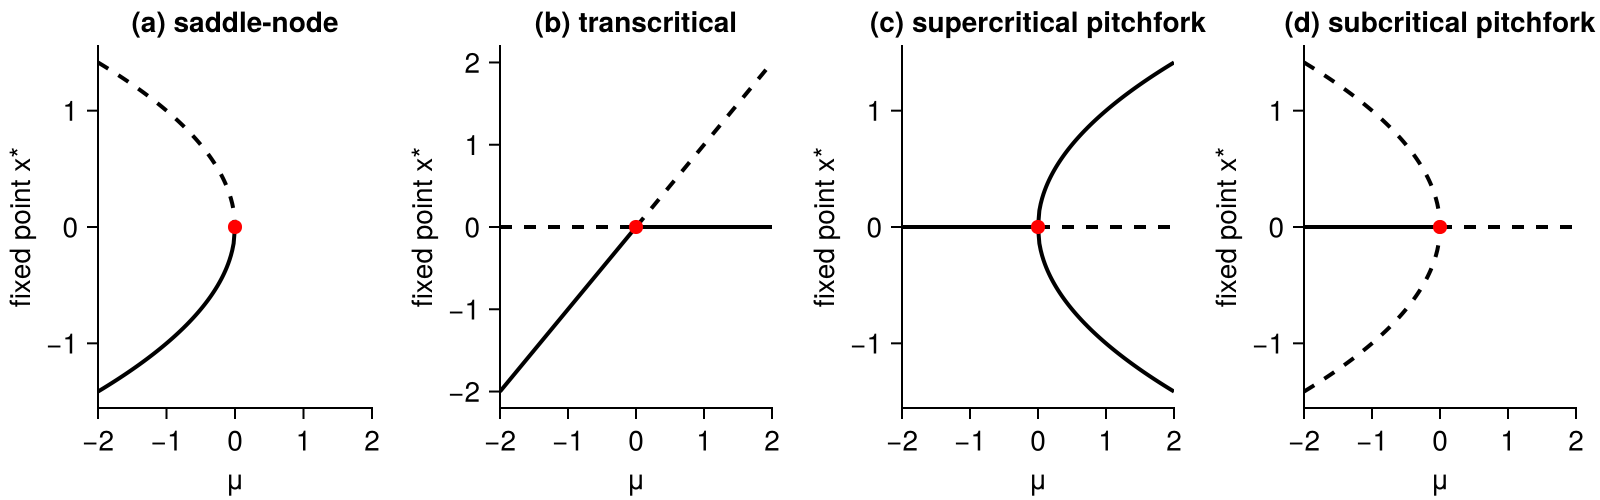

In [5]:
let absμmax = 2, ifsave=true
    fig = Figure(size=(800, 250), figure_padding=(3, 12, 3, 3))
    axopts = (
        xlabel="μ", xgridvisible=false,
        ylabel="fixed point x*", ygridvisible=false,
    )
    ax1 = Axis(fig[1, 1]; title="(a) saddle-node", axopts...)
    ax2 = Axis(fig[1, 2]; title="(b) transcritical", axopts...)
    ax3 = Axis(fig[1, 3]; title="(c) supercritical pitchfork", axopts...)
    ax4 = Axis(fig[1, 4]; title="(d) subcritical pitchfork", axopts...)
    
    μneg = collect(range(-absμmax, 0, 101))
    μpos = collect(range(0, absμmax, 101))
    lineopts = (color=:black, linewidth=2)

    # saddle-node
    lines!(ax1, μneg, -sqrt.(-μneg); lineopts...)
    lines!(ax1, μneg, sqrt.(-μneg); linestyle=:dash, lineopts...)

    # transcritical
    lines!(ax2, μneg, zeros(length(μneg)); linestyle=:dash, lineopts...)
    lines!(ax2, μneg, μneg; lineopts...)
    lines!(ax2, μpos, zeros(length(μpos)); lineopts...)
    lines!(ax2, μpos, μpos; linestyle=:dash, lineopts...)

    # superctical pitchfork
    lines!(ax3, μneg, zeros(length(μneg)); lineopts...)
    lines!(ax3, μpos, zeros(length(μpos)); linestyle=:dash, lineopts...)
    lines!(ax3, μpos, sqrt.(μpos); lineopts...)
    lines!(ax3, μpos, -sqrt.(μpos); lineopts...)

    # subcritical pitchfork
    lines!(ax4, μneg, zeros(length(μneg)); lineopts...)
    lines!(ax4, μpos, zeros(length(μpos)); linestyle=:dash, lineopts...)
    lines!(ax4, μneg, sqrt.(-μneg); linestyle=:dash, lineopts...)
    lines!(ax4, μneg, -sqrt.(-μneg); linestyle=:dash, lineopts...)
    
    # finalise styles
    for ax in (ax1, ax2, ax3, ax4)
        hidespines!(ax, :t, :r)
        xlims!(ax, -absμmax, absμmax)
        # mark bifurcation points
        scatter!(ax, [0,], [0,], color=:red, markersize=10)
    end

    if ifsave
        save("output/fig-zero-eig-bifur.pdf", fig)
    end

    display(fig)
end;